In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

In [2]:
df= pd.read_excel(r"C:\Users\tocha\Downloads\DiariosSanFernandoINTA.xls")
df.head()

,Fecha,Temperatura_Abrigo_150cm,Temperatura_Abrigo_150cm_Maxima,Temperatura_Abrigo_150cm_Minima,Temperatura_Intemperie_5cm_Minima,Temperatura_Intemperie_50cm_Minima,Temperatura_Suelo_5cm_Media,Temperatura_Suelo_10cm_Media,Temperatura_Inte_5cm,Temperatura_Intemperie_150cm_Minima,...,Duracion_Follaje_Mojado,Velocidad_Viento_200cm_Media,Direccion_Viento_200cm,Velocidad_Viento_1000cm_Media,Direccion_Viento_1000cm,Velocidad_Viento_Maxima,Presion_Media,Radiacion_Global,Horas_Frio,Unidades_Frio
0,2018-02-08 00:00:00.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,,NaN,,NaN,NaN,NaN,NaN,NaN
1,2018-02-09 00:00:00.0,23.80764,28.6,20.4,NaN,NaN,NaN,26.21042,NaN,NaN,...,NaN,1.332639,C,1.665799,C,19.3,NaN,NaN,0.0,-23.904030
2,2018-02-10 00:00:00.0,24.51389,31.7,19.4,NaN,NaN,NaN,26.45972,NaN,NaN,...,NaN,1.638195,C,2.047743,C,19.0,NaN,NaN,0.0,-23.904030
3,2018-02-11 00:00:00.0,19.50139,24.2,15.1,NaN,NaN,NaN,24.66320,NaN,NaN,...,NaN,3.247224,E,4.059030,C,20.4,NaN,NaN,0.0,-15.106020
4,2018-02-12 00:00:00.0,16.70625,24.6,9.5,NaN,NaN,NaN,22.63611,NaN,NaN,...,NaN,1.027778,C,1.284722,C,13.4,NaN,NaN,0.0,-5.394994


In [27]:
df_limpio= df[['Temperatura_Abrigo_150cm_Maxima',
                'Temperatura_Abrigo_150cm_Minima',
                'Precipitacion_Pluviometrica',
                'Velocidad_Viento_Maxima',
                'Rocio_Medio',
                'Humedad_Media', 'Tesion_Vapor_Media']].dropna().copy()  #Crea un df nuevo solo con las columnas pedidas y eliminando las filas con NANs

df_limpio.rename({'Temperatura_Abrigo_150cm_Maxima' : 'temperaturaMaxima',
                   'Temperatura_Abrigo_150cm_Minima' : 'temperaturaMinima',
                   'Precipitacion_Pluviometrica' : 'precipitacion',
                   'Humedad_Media' : 'humedad',
                   'Rocio_Medio' : 'rocio',
                   'Velocidad_Viento_Maxima' : 'viento', 
                   'Tesion_Vapor_Media': 'vapor'},
                axis=1, inplace=True) # .rename se alimenta de un diccionario donde las keys son los nombres actuales de las columnas y los values los nombres nuevos
                                     #   axis=1 si se pone pandas busca filas con esos nombres, no los encuentra y no cambia los nombres de las columnas.
                                     #  inplace=True si no se pone pandas crea otro df con los nombres nuevos.

In [30]:
df_limpio['llueveBinario']= 0 #crea columna con 0
indice= df_limpio['precipitacion'] > 0 # indice es una columna invisible con True cuando precipitación es mayor a 0
#print(type(indice))
df_limpio.loc[indice, 'llueveBinario']= 1 #.loc ubica datos usando nombres de filas y columnas // indice: tiene info de fila y T o F, para True le asigna valor 1 a esa fila en la columna 'llueveBinario'
df_limpio['llueveBinario'].value_counts()

llueveBinario
0    717
1    337
Name: count, dtype: int64

Claramente estpa no balanceado la cantidad de datos que llueve con la que no llueve, no confiar en accuracy

Modelando con 2 features: temperatura mínima y humedad:

In [5]:
features= ['temperaturaMinima', 'humedad']

X= df_limpio[features].values
y= df_limpio['llueveBinario']

modelo_clasificador= LogisticRegression()
modelo_clasificador.fit(X,y)
accuracy= modelo_clasificador.score(X,y)

print(f'El acuracy del modelo es de: {round(accuracy,4)}')

El acuracy del modelo es de: 0.7125


Al estar desbalanceados los datos, si uso un modelo que dice que nunca llueve obtengo un accuracy de 0.68 por lo que no sirve el accuracy.  
podría normalizar el accuracy???????

Armo matriz de confusión con días que llueve positivos  
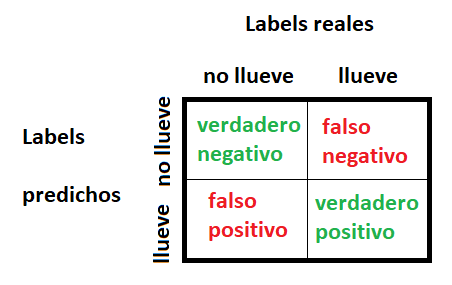

In [6]:
y_estimado= modelo_clasificador.predict(X)
print(y_estimado)

cm= confusion_matrix(y_estimado, y)
print(cm)

cm_normalizada= confusion_matrix(y_estimado, y, normalize='true')
print(cm_normalizada)

[0 0 0 ... 0 0 0]
[[643 229]
 [ 74 108]]
[[0.73738532 0.26261468]
 [0.40659341 0.59340659]]


73% predijo bien que no llovía, y 59% predijo bien que si llovía

Ahora uso el balanced accuracy

In [7]:
def balanced_accuracy(cm):
    sensibilidad= cm[1,1] / (cm[1,1] + cm[0,1])
    especificidad= cm[0,0] / (cm[1,0] + cm[0,0])
    ba= (sensibilidad + especificidad) /2
    return [sensibilidad, especificidad, ba]

metricas= balanced_accuracy(cm)

print('Matriz de confusion del modelo es:')
print(cm)
print('Sensibilidad del modelo es de: {}'.format(round(metricas[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas[1],4)))
print('BA del modelo es de: {}'.format(round(metricas[2],4)))


Matriz de confusion del modelo es:
[[643 229]
 [ 74 108]]
Sensibilidad del modelo es de: 0.3205
Especificidad del modelo es de: 0.8968
BA del modelo es de: 0.6086


Grafico de los datos en el espacio de las features

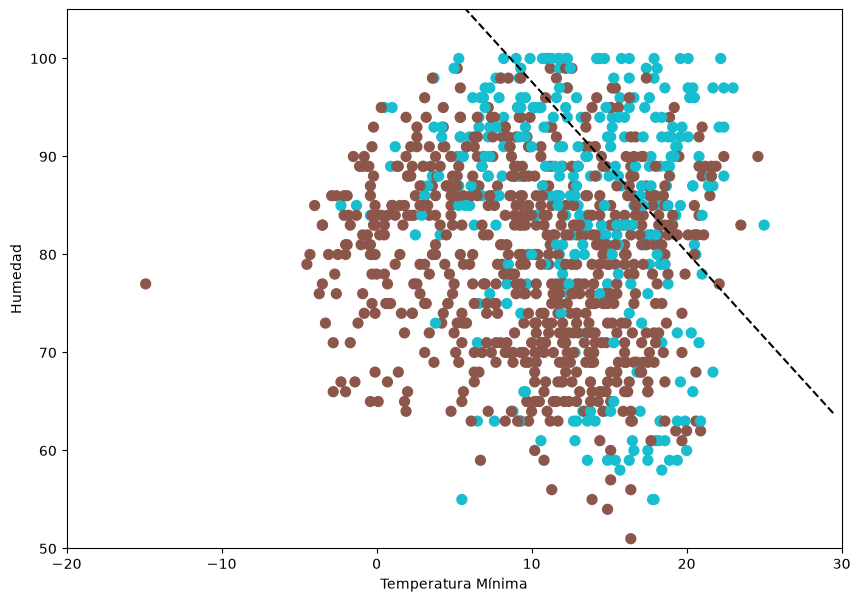

In [ ]:
def grafica_modelo_2D(X,y, modelo):

    beta_0= modelo.intercept_
    beta_1= modelo.coef_[0][0]  #Saca los coefs del modelo
    beta_2= modelo.coef_[0][1]

    fig, ax= plt.subplots(figsize= (10,7))
    mi_cmap= ListedColormap(['tab:brown', 'tab:cyan']) #creo mi mapa de colores

    ax.scatter(X[:,0], X[:,1], c=y, #color de puntos según la etiqueta real (si llovió o no)
               cmap=mi_cmap, s=50)
    ax.set_xlabel('Temperatura Mínima')
    ax.set_ylabel('Humedad')

    x_1_test= np.arange(-20,30,0.5) #Creo array de puntos en x (temepratura minima), luego le aplico el modelo y obtengo los y (humedad)
    ax.plot(x_1_test, -(beta_0 + x_1_test * beta_1) / beta_2, linestyle= 'dashed', color= 'k')

    ax.axis([-20,30,50,105])
    plt.show()

grafica_modelo_2D(X,y,modelo_clasificador)

la recta tiende a priorizar que los días sin lluvia estén bien clasificados debido a que hay mucho más días sin lluvia en el dataser por lo que clasificarlos bien reduce la función pérdida.

voy a eliminar aleatoriamente datos de días sin lluvia hasta que tengan el mismo len (es una mala práctica pues pierdo info de los datos)

337
337
El accuracy del modelo es de: 0.6617
Matriz de confusion del modelo es:
[[221 112]
 [116 225]]
Sensibilidad del modelo es de: 0.6677
Especificidad del modelo es de: 0.6558
BA del modelo es de: 0.6617


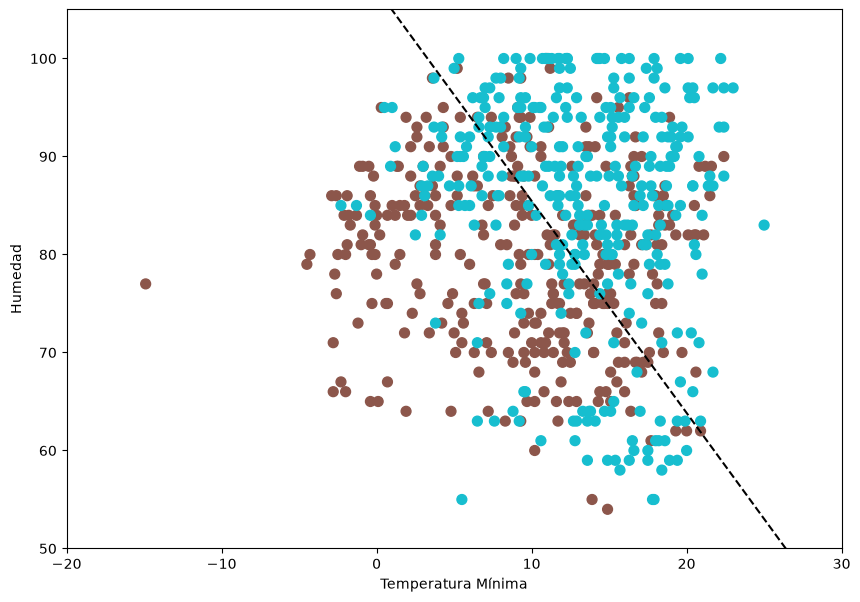

In [20]:
# indice de cada categoría de y (llueveBinario)
index_y0= np.where(y==0)[0]
index_y1= np.where(y==1)[0]

#cant de observaciones de cada categoría
n_y0= len(index_y0)
n_y1= len(index_y1)

#crea un conjunto de datos del tamaño del otro conjunto asegurando que no se repitan (con replace false)
index_mantener= np.random.choice(index_y0, size= n_y1, replace=False)
#crea un array de indices con ambos conjuntos
index_row= np.concatenate((index_mantener, index_y1), axis=0) 

X_balance= X[index_row, 0:] #crea array con los datos X de esos indices
y_balance= np.asarray(y)[index_row] #lo mismo con y

print(len(y_balance[y_balance==0])) # veo que efectivamente tengo la misma cantidad de 0 que 1
print(len(y_balance[y_balance==1]))

#entreno y evaluo el modelo con estos datos
modelo_balanceado= LogisticRegression()
modelo_balanceado.fit(X_balance, y_balance)
accuracy= modelo_balanceado.score(X_balance, y_balance)
beta_0 = modelo_balanceado.intercept_ # El beta 0
beta_1 = modelo_balanceado.coef_[0][0] # El coeficiente beta_1
beta_2 = modelo_balanceado.coef_[0][1] # El coeficiente beta_2

y_estimado_balance= modelo_balanceado.predict(X_balance)
cm= confusion_matrix(y_estimado_balance, y_balance)
ba= balanced_accuracy(cm)

print('El accuracy del modelo es de: {}'.format(round(accuracy,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm)
print('Sensibilidad del modelo es de: {}'.format(round(ba[0],4)))
print('Especificidad del modelo es de: {}'.format(round(ba[1],4)))
print('BA del modelo es de: {}'.format(round(ba[2],4)))

grafica_modelo_2D(X_balance,y_balance,modelo_balanceado)


enohorabuena la frontera pasa por el centro de la nube de puntos.

Balanceados los datos BA y accuracy son iguales. no me da igual al original por la aleatoriedad de eliminar datos, cada que corro la celda cambia todo.

## Balanceado por frecunecia de clases
mejor forma de solucionar desbalances.
adaptar la penalización por clasificación incorrecta dependiendo de la frecunecia con la que aparece cada etiqueta. Si una etiqueta es más frecuente hay menor penalización asociada.

El accuracy del modelo es de: 0.667
Matriz de confusion del modelo es:
[[479 113]
 [238 224]]
Sensibilidad del modelo es de: 0.6647
Especificidad del modelo es de: 0.6681
BA del modelo es de: 0.6664


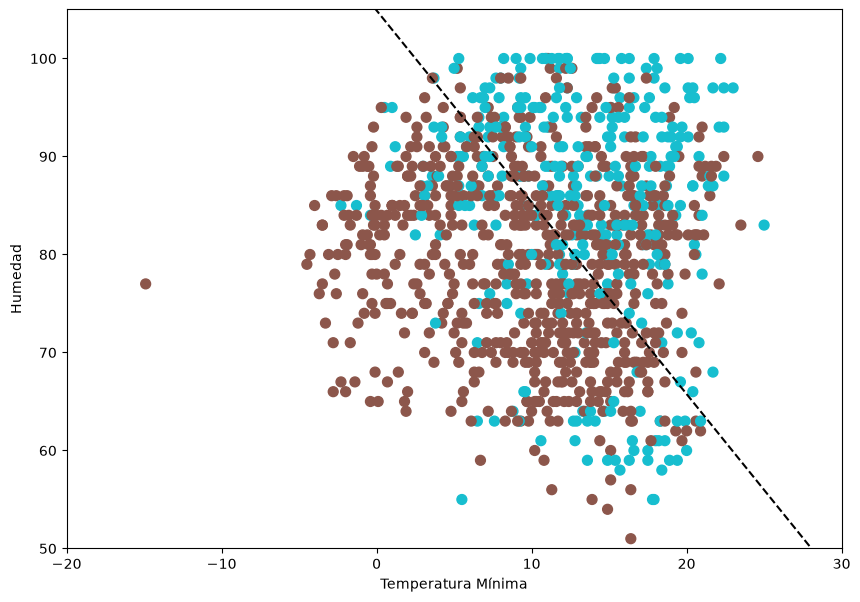

In [23]:
modelo_pena= LogisticRegression(class_weight= 'balanced')
modelo_pena.fit(X,y)
accuracy= modelo_pena.score(X,y)
beta_0 = modelo_pena.intercept_ # El beta 0
beta_1 = modelo_pena.coef_[0][0] # El coeficiente beta_1
beta_2 = modelo_pena.coef_[0][1] # El coeficiente beta_2

y_estimado= modelo_pena.predict(X)
cm=confusion_matrix(y_estimado, y)
ba= balanced_accuracy(cm)

print('El accuracy del modelo es de: {}'.format(round(accuracy,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm)
print('Sensibilidad del modelo es de: {}'.format(round(ba[0],4)))
print('Especificidad del modelo es de: {}'.format(round(ba[1],4)))
print('BA del modelo es de: {}'.format(round(ba[2],4)))

grafica_modelo_2D(X,y,modelo_pena)

nuevamente ba y accuracy son similares.
fuerza a la recta a pasar entre la nube de puntos de manera más "centrada".

## Tipos de error
La forma en que la recta atraviesa la nube de puntos no refleja un único concepto de performance del algoritmo, porque ese concepto no existe.  
Si es muy importante detectar los días de lluvia podemos poner un peso comparativamente más grande a la etiqueta y=1.

El score del modelo es de: 0.3672
Matriz de confusion del modelo es:
[[ 52   2]
 [665 335]]
Sensibilidad del modelo es de: 0.9941
Especificidad del modelo es de: 0.0725
BA del modelo es de: 0.5333


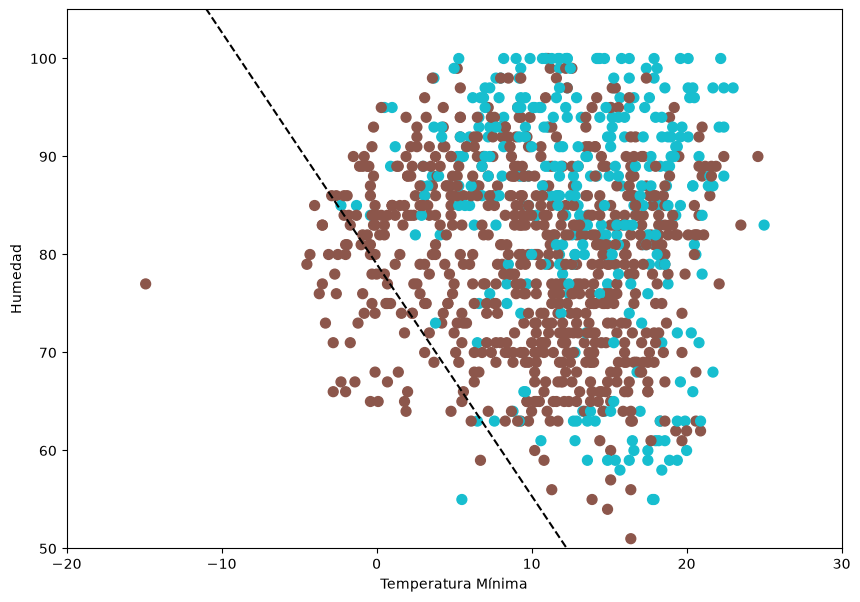

In [24]:
# diccionario donde las keys son las etiquetas de Y y los values son el peso.
pesos= {0:0.1, 1:1}

regLog= LogisticRegression(class_weight= pesos)
regLog.fit(X, y) # Ajustamos el modelo con los parámetros
score = regLog.score(X,y) # Calculamos el score
beta_0 = regLog.intercept_ # El beta 0
beta_1 = regLog.coef_[0][0] # El coeficiente beta_1
beta_2 = regLog.coef_[0][1] # El coeficiente beta_2

ypred = regLog.predict(X) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm = confusion_matrix(ypred, y) # primera entrada son las etiquetas predichas, segunda son las reales
metricas = balanced_accuracy(cm)

print('El score del modelo es de: {}'.format(round(score,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm)
print('Sensibilidad del modelo es de: {}'.format(round(metricas[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas[1],4)))
print('BA del modelo es de: {}'.format(round(metricas[2],4)))

grafica_modelo_2D(X,y,regLog)

en la mc se ve que solo 2 días de lluvia los clasifica mal. pero muchos días de no lluvia clasificados como lluvia erroneamente. En el gráfico se ve que la linea de división está sesgada para que todos los ejemplos de lluvua queden siemrpe del mismo lado. 

Muchos falsos positivos.  

tratar de que no se escape ningún caso positivo aumenta el error tipo 1 (falsos negativos) .  
Trarar de que no se escape ningún caso negativo aumenta el error tipo 2 (falsos positivos).

# Para llevarse de este notebook



*   El score por defecto ("accuracy") puede no ser muy bueno para medir la performance de un clasificador si los datos no están balanceados. En ese caso, recomendamos visualizar la matriz de confusión:



```
from sklearn.metrics import confusion_matrix

ypred = regLog.predict(X) # con esto obtengo la predicción de las etiquetas en base a mis datos

cm = confusion_matrix(ypred, y) # primera entrada son las etiquetas predichas, segunda son las reales

print(cm)
```

*   Si queremos resumir la performance en un único número, podemos considerar el promedio de la especificidad y la sensibilidad:

```
def balanced_accuracy(cm):
  sensibilidad = cm[0,0]/(cm[0,0]+cm[1,0])
  especificidad = cm[1,1]/(cm[1,1]+cm[0,1])
  return [sensibilidad, especificidad, (sensibilidad + especificidad)/2]
```

*   Si tenemos datos no balanceados, una opción es subsamplear la clase más prevalente. Pero tiene la desventaja de que perdemos datos. Otra forma de hacerlo es penalizando las clasificaciones erróneas de distinta forma dependiendo de la clase. Se puede hacer tanto balanceado:


```
regLog = LogisticRegression(penalty = 'none', class_weight='balanced') #
```

*   Como por pesos especificados a mano para cada una de las clases:

```
peso = {0:0.5, 1:1}

regLog = LogisticRegression(penalty = 'none', class_weight=pesos) #
```

*   Vimos que hay dos tipos de errores que puedo cometer, asociados a la cantidad de falsos positivos (tipo 1) y falsos negativos (tipo 2).








# Preguntas extra

1.   Supongamos que desarrollás un método para diagnosticar una enfermedad grave, por ejemplo, HIV (la presencia de HIV cuenta  como "positivo"). ¿Qué error te parece más grave: tipo 1 (falsos positivos), tipo 2 (falsos negativos), o ambos por igual?
2.   Supongamos que trabajás programando drones letales dedicados a identificar y asesinar a ciertos criminales prófugos (detectar a un criminal cuenta como "positivo"). ¿Qué error te parece más grave: tipo 1 (falsos positivos), tipo 2 (falsos negativos), o ambos por igual?
3.   Supongamos que desarrollás un sistema automático para detectar y responder a ataques termonucleares a partir de datos de radar (un ataque cuenta como "positivo"). ¿Qué error te parece más grave: tipo 1 (falsos positivos), tipo 2 (falsos negativos), o ambos por igual?



# feature engineering
en jerga de machine learning, las variables (columnas de la matriz X) se denominan features. el proceso de feature engineering consiste en modificar nuestras features o expandirlas para hacerle el trabajo más fácil al clasificador. Para esto usamos nuestra intuición, 

In [32]:
from sklearn.preprocessing import MinMaxScaler

ahora con 5 features

In [34]:
features= ['temperaturaMinima', 'temperaturaMaxima', 'humedad', 'rocio', 'vapor']
X= df_limpio[features].values
print(X.shape)
y= df_limpio['llueveBinario']

scaler= MinMaxScaler() # Normaliza los datos al intervalo [0,1]
scaler.fit(X)
X= scaler.transform(X)

logreg= LogisticRegression(class_weight='balanced', max_iter=10000)
logreg.fit(X,y)
score= logreg.score(X,y)

ypred= logreg.predict(X)
cm = confusion_matrix(ypred, y)
metricas = balanced_accuracy(cm)

print('El score del modelo es de: {}'.format(round(score,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm)
print('Sensibilidad del modelo es de: {}'.format(round(metricas[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas[1],4)))
print('BA del modelo es de: {}'.format(round(metricas[2],4)))



(1054, 5)
El score del modelo es de: 0.6774
Matriz de confusion del modelo es:
[[490 113]
 [227 224]]
Sensibilidad del modelo es de: 0.6647
Especificidad del modelo es de: 0.6834
BA del modelo es de: 0.674


se agregan términos cuadráticos y cúbicos:

In [36]:
X_1= np.concatenate((X, X**2, X**3, X**4, X**5), axis=1)
scaler= MinMaxScaler()
scaler.fit(X_1)
X_1= scaler.transform(X_1)

regLog_1 = LogisticRegression(class_weight='balanced', max_iter=10000) # Inicializamos nuevamente el modelo. max_iter es la cantidad de iteraciones maximas del algoritmo de optimizacion de parametros antes de detenerse.
regLog_1.fit(X_1, y) # Ajustamos el modelo con los parámetros
score = regLog_1.score(X_1,y) # Calculamos el score

ypred = regLog_1.predict(X_1) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm = confusion_matrix(ypred, y) # primera entrada son las etiquetas predichas, segunda son las reales
metricas = balanced_accuracy(cm)

print('El score del modelo es de: {}'.format(round(score,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm)
print('Sensibilidad del modelo es de: {}'.format(round(metricas[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas[1],4)))
print('BA del modelo es de: {}'.format(round(metricas[2],4)))



El score del modelo es de: 0.7173
Matriz de confusion del modelo es:
[[537 118]
 [180 219]]
Sensibilidad del modelo es de: 0.6499
Especificidad del modelo es de: 0.749
BA del modelo es de: 0.6994


Parece que BA merjora.
Tiene mejor performance este modelo que el anterior pero puede estar overfitteando.

# Train - Test split
Una forma de ver que no está overfitteando es separar parte de los datos para entrenar el modelo (obtener los parámetros) y dejar otra parte para evaluar la performance del modelo. Pueden pasar estas cosas:  
* **La performance es baja en el set de entrenamiento y baja en el set de evaluación** En este caso, necesito o más datos, o más features (puedo probar arefar features que ya tenía transformándolos).

* **La performance es alta en el set de entrenamiento y baja en el set de evalucación.** En este caso, estoy overfitteando. Puedo intentar resolver esto sumando más datos a mi modelo, o vien aplicando regularización.

* **La performance es alta en el set de entrenamiento y alta en el set de evaluación.** El caso idela: apendí parámetros que me sirven para generalizar a datos nuevos sin overfittear.



In [38]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.15)

scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
scaler.fit(X_train) # encuentro los parametros para el escaleo
X_train = scaler.transform(X_train) # aplico la transformacion

scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
scaler.fit(X_test) # encuentro los parametros para el escaleo
X_test = scaler.transform(X_test) # aplico la transformacion

# OBLIGATORIO HACER LA NORMALIZACIÓN DE LOS DATOS POR SEPARADO EN LOS SETS DE TRAIN Y TEST

regLog = LogisticRegression(class_weight='balanced', max_iter=10000) # Inicializamos nuevamente el modelo
regLog.fit(X_train, y_train) # Ajustamos el modelo con los parámetros

score_train = regLog.score(X_train,y_train) # Calculamos el score
ypred_train = regLog.predict(X_train) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm_train = confusion_matrix(ypred_train, y_train) # primera entrada son las etiquetas predichas, segunda son las reales
metricas_train = balanced_accuracy(cm_train)

print('Para TRAIN set:')
print('El score del modelo es de: {}'.format(round(score_train,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm_train)
print('Sensibilidad del modelo es de: {}'.format(round(metricas_train[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas_train[1],4)))
print('BA del modelo es de: {}'.format(round(metricas_train[2],4)))
print('\n')

score_test= regLog.score(X_test,y_test) # Calculamos el score
ypred_test= regLog.predict(X_test) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm_test = confusion_matrix(ypred_test, y_test) # primera entrada son las etiquetas predichas, segunda son las reales
metricas_test = balanced_accuracy(cm_test)


print('Para TEST set:')
print('El score del modelo es de: {}'.format(round(score_test,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm_test)
print('Sensibilidad del modelo es de: {}'.format(round(metricas_test[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas_test[1],4)))
print('BA del modelo es de: {}'.format(round(metricas_test[2],4)))


Para TRAIN set:
El score del modelo es de: 0.6771
Matriz de confusion del modelo es:
[[422  99]
 [190 184]]
Sensibilidad del modelo es de: 0.6502
Especificidad del modelo es de: 0.6895
BA del modelo es de: 0.6699


Para TEST set:
El score del modelo es de: 0.6855
Matriz de confusion del modelo es:
[[84 29]
 [21 25]]
Sensibilidad del modelo es de: 0.463
Especificidad del modelo es de: 0.8
BA del modelo es de: 0.6315


en general es pero la performance en el test set.  
si subo test_size mejora el test set, no entiendo, debería ser al revez.  
que es una fluctuación estocástica por armar el train-test split? Es la variación aleatoria de resultados de performance por la aleatoriedad de los datos elegido para el split.


ahora con features polinómicos

In [44]:
# Definamos la matriz X
campos = ['temperaturaMinima', 'temperaturaMaxima', 'humedad', 'rocio', 'vapor'] # Lista que contiene las features de interés.
X = df_limpio[campos].values # En este caso no hace falta reshapear, porque ya tiene la forma que queremos

X_temp= X
for i in np.arange(2,5):
    X_temp= np.concatenate((X_temp, X**i), axis=1)
X_1= X_temp

X_train, X_test, y_train, y_test = train_test_split(X_1, y, test_size=0.3)

scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
scaler.fit(X_train) # encuentro los parametros para el escaleo
X_train = scaler.transform(X_train) # aplico la transformacion

scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
scaler.fit(X_test) # encuentro los parametros para el escaleo
X_test = scaler.transform(X_test) # aplico la transformacion

regLog_1 = LogisticRegression(class_weight='balanced', max_iter=50000) # Inicializamos nuevamente el modelo
regLog_1.fit(X_train, y_train) # Ajustamos el modelo con los parámetros

score_train = regLog_1.score(X_train,y_train) # Calculamos el score
ypred_train = regLog_1.predict(X_train) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm_train = confusion_matrix(ypred_train, y_train) # primera entrada son las etiquetas predichas, segunda son las reales
metricas_train = balanced_accuracy(cm_train)

print('Para TRAIN set:')
print('El score del modelo es de: {}'.format(round(score_train,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm_train)
print('Sensibilidad del modelo es de: {}'.format(round(metricas_train[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas_train[1],4)))
print('BA del modelo es de: {}'.format(round(metricas_train[2],4)))
print('\n')

score_test= regLog_1.score(X_test,y_test) # Calculamos el score
ypred_test= regLog_1.predict(X_test) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm_test = confusion_matrix(ypred_test, y_test) # primera entrada son las etiquetas predichas, segunda son las reales
metricas_test = balanced_accuracy(cm_test)


print('Para TEST set:')
print('El score del modelo es de: {}'.format(round(score_test,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm_test)
print('Sensibilidad del modelo es de: {}'.format(round(metricas_test[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas_test[1],4)))
print('BA del modelo es de: {}'.format(round(metricas_test[2],4)))


Para TRAIN set:
El score del modelo es de: 0.7069
Matriz de confusion del modelo es:
[[368  76]
 [140 153]]
Sensibilidad del modelo es de: 0.6681
Especificidad del modelo es de: 0.7244
BA del modelo es de: 0.6963


Para TEST set:
El score del modelo es de: 0.6877
Matriz de confusion del modelo es:
[[146  36]
 [ 63  72]]
Sensibilidad del modelo es de: 0.6667
Especificidad del modelo es de: 0.6986
BA del modelo es de: 0.6826


En el codigo del profe le da pero el Test set indicando que está overfitteando. A mi me da igual, ni idea por que.

Se prueba ahora con regularización Ridge (pentalty='l2') para que los coefs no tomen valores muy altos.

In [46]:
# Definamos la matriz X
campos = ['temperaturaMinima', 'temperaturaMaxima', 'humedad', 'rocio', 'vapor'] # Lista que contiene las features de interés.
X = df_limpio[campos].values # En este caso no hace falta reshapear, porque ya tiene la forma que queremos


X_temp = X
for i in np.arange(2,5):
    X_temp = np.concatenate((X_temp,X**i), axis=1)
X_1 = X_temp


X_train, X_test, y_train, y_test = train_test_split(X_1, y, test_size=0.3)

scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
scaler.fit(X_train) # encuentro los parametros para el escaleo
X_train = scaler.transform(X_train) # aplico la transformacion

scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
scaler.fit(X_test) # encuentro los parametros para el escaleo
X_test = scaler.transform(X_test) # aplico la transformacion

regLog_1 = LogisticRegression(penalty = 'l2', class_weight='balanced', max_iter=10000) # Inicializamos nuevamente el modelo
regLog_1.fit(X_train, y_train) # Ajustamos el modelo con los parámetros

score_train = regLog_1.score(X_train,y_train) # Calculamos el score
ypred_train = regLog_1.predict(X_train) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm_train = confusion_matrix(ypred_train, y_train) # primera entrada son las etiquetas predichas, segunda son las reales
metricas_train = balanced_accuracy(cm_train)

print('Para TRAIN set:')
print('El score del modelo es de: {}'.format(round(score_train,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm_train)
print('Sensibilidad del modelo es de: {}'.format(round(metricas_train[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas_train[1],4)))
print('BA del modelo es de: {}'.format(round(metricas_train[2],4)))
print('\n')

score_test= regLog_1.score(X_test,y_test) # Calculamos el score
ypred_test= regLog_1.predict(X_test) # con esto obtengo la predicción de las etiquetas en base a mis datos
cm_test = confusion_matrix(ypred_test, y_test) # primera entrada son las etiquetas predichas, segunda son las reales
metricas_test = balanced_accuracy(cm_test)


print('Para TEST set:')
print('El score del modelo es de: {}'.format(round(score_test,4))) # Le pido que printee el score del modelo. Le pido que lo haga con 4 cifras significativas
print('Matriz de confusion del modelo es:')
print(cm_test)
print('Sensibilidad del modelo es de: {}'.format(round(metricas_test[0],4)))
print('Especificidad del modelo es de: {}'.format(round(metricas_test[1],4)))
print('BA del modelo es de: {}'.format(round(metricas_test[2],4)))

Para TRAIN set:
El score del modelo es de: 0.6866
Matriz de confusion del modelo es:
[[352  81]
 [150 154]]
Sensibilidad del modelo es de: 0.6553
Especificidad del modelo es de: 0.7012
BA del modelo es de: 0.6783


Para TEST set:
El score del modelo es de: 0.7382
Matriz de confusion del modelo es:
[[179  47]
 [ 36  55]]
Sensibilidad del modelo es de: 0.5392
Especificidad del modelo es de: 0.8326
BA del modelo es de: 0.6859


c:\Users\tocha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


# Optimización de hiperparámetros
Para que elección de hiperparámetros maximizo la performance del clasificador en el dataset test?

procedimiento:

1. Generar una función que entrena y evalua el clasificador usando un train-test split, que incorpora como input los hiperparámetros

2. Para cada elección hiperparámetros, se repite este procedimiento varias veces y se usa la performance promedio. Para evitar aleatoriedades estocásticas.

3. Se reptie para todas las combinaciones de hiperparámetos y se encuentra aquella que maximiza la performance del clasificador.


In [51]:
def classifier(X,y,n,c): # los hiperparámetros son el grado de exponente y la constante de regularización
    
  X_temp = X
  for i in np.arange(2,n):
    X_temp = np.concatenate((X_temp,X**i), axis=1)
  X = X_temp

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

  scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
  scaler.fit(X_train) # encuentro los parametros para el escaleo
  X_train = scaler.transform(X_train) # aplico la transformacion

  scaler = MinMaxScaler() # primero creo un objeto MinMaxScaler. Por defecto, esto normaliza los datos al intervalo [0,1]
  scaler.fit(X_test) # encuentro los parametros para el escaleo
  X_test = scaler.transform(X_test) # aplico la transformacion

  regLog = LogisticRegression(l1_ratio=0, class_weight='balanced', C=c, max_iter=10000)
  regLog.fit(X_train, y_train)

  ypred_train = regLog.predict(X_train) # con esto obtengo la predicción de las etiquetas en base a mis datos
  cm_train = confusion_matrix(ypred_train, y_train) # primera entrada son las etiquetas predichas, segunda son las reales
  metricas_train = balanced_accuracy(cm_train)

  ypred_test = regLog.predict(X_test) # con esto obtengo la predicción de las etiquetas en base a mis datos
  cm_test= confusion_matrix(ypred_test, y_test) # primera entrada son las etiquetas predichas, segunda son las reales
  metricas_test = balanced_accuracy(cm_test)

  return metricas_train[2], metricas_test[2]

In [52]:
BA_train, BA_test = classifier(X,y,6,1)
print(BA_train, BA_test)

# aumento C

BA_train, BA_test = classifier(X,y,6,1000)
print(BA_train, BA_test)

# disminuyo C

BA_train, BA_test = classifier(X,y,6,0.0001)
print(BA_train, BA_test)

0.6838861096673596 0.6666928227662691
0.6914214183527487 0.631161971830986
0.6750237539949901 0.6837725076855512


In [53]:
iterations = 100 # esto se puede poner en 100 para que no tarde mil años durante la clase


n_values = np.arange(1,7) # rango de potencias maximas
c_values = np.arange(0.2,5,0.2) # rango de constantes de regularizacion


mean_BA_train = np.zeros((len(n_values),len(c_values))) #  los arrays con los balanced accuracy para cada combinacion de hiperparametros, para train y test
mean_BA_test = np.zeros((len(n_values),len(c_values)))

for xx,n in enumerate(n_values): # itero sobre n
    for yy,c in enumerate(c_values): # itero sobre c
      BA_test_temp = [] # variables temporales para ir poniendo los resultados a lo largo de las iteraciones
      BA_train_temp = []
      print([n,c]) # esto es para los ansiosos
      for it in np.arange(iterations): # itero
          BA_train, BA_test = classifier(X,y,n,c)  # calculo las balanced accuracy para esos hiperparametros
          BA_test_temp.append(BA_test) # agrego a las variables temporales
          BA_train_temp.append(BA_train)
      mean_BA_train[xx,yy] = np.mean(BA_train_temp) # calculo promedios
      mean_BA_test[xx,yy] = np.mean(BA_test_temp)

[np.int64(1), np.float64(0.2)]
[np.int64(1), np.float64(0.4)]
[np.int64(1), np.float64(0.6000000000000001)]
[np.int64(1), np.float64(0.8)]
[np.int64(1), np.float64(1.0)]
[np.int64(1), np.float64(1.2)]
[np.int64(1), np.float64(1.4000000000000001)]
[np.int64(1), np.float64(1.6)]
[np.int64(1), np.float64(1.8)]
[np.int64(1), np.float64(2.0)]
[np.int64(1), np.float64(2.2)]
[np.int64(1), np.float64(2.4000000000000004)]
[np.int64(1), np.float64(2.6000000000000005)]
[np.int64(1), np.float64(2.8000000000000003)]
[np.int64(1), np.float64(3.0000000000000004)]
[np.int64(1), np.float64(3.2)]
[np.int64(1), np.float64(3.4000000000000004)]
[np.int64(1), np.float64(3.6000000000000005)]
[np.int64(1), np.float64(3.8000000000000003)]
[np.int64(1), np.float64(4.0)]
[np.int64(1), np.float64(4.2)]
[np.int64(1), np.float64(4.4)]
[np.int64(1), np.float64(4.6000000000000005)]
[np.int64(1), np.float64(4.800000000000001)]
[np.int64(2), np.float64(0.2)]
[np.int64(2), np.float64(0.4)]
[np.int64(2), np.float64(0.600